# Notebook 6: how stable are the recovered densities?

This notebook compares support, resolution and smoothing choices on two synthetic benchmarks. The code cell reruns all 14 joint fits and can take several minutes. Rerun `build_milestone6_notebook.py` to refresh the generated text, tables and embedded figures together. The first five notebooks and both earlier interactive companions are unchanged.


# Assessing the stability of the recovered densities
## Milestone 6: support, resolution, smoothing and a non-lognormal benchmark
Joel Cerraga | Quant research project | Development version 0.6

**Status:** this is a controlled synthetic sensitivity study. It compares seven declared fitting choices for each of two known benchmark families. The results distinguish calendar consistency, price accuracy, density accuracy and tail-summary stability. No empirical SPX calibration or statistical confidence interval is produced.

### 1. Moving from consistency to stability

Milestone 5 linked the maturity slices and checked their normalised call ordering between bin boundaries. That addressed an internal consistency problem. It did not establish that the inferred tails were accurate or insensitive to modelling choices. The remaining tail bump in Figure 13 made this distinction visible.

As Malz (2014) explains in *A Simple and Reliable Way to Compute Option-Based Risk-Neutral Distributions* [14, §§2.3, 3.2], completing a density beyond observed strikes involves extrapolation, and tail summaries depend on how that extrapolation is handled. His paper uses a different estimator. Here, the finite histogram support and its smoothing penalty are explicit extrapolation assumptions to be tested.

The study asks three practical questions. Does refining the histogram change the answer? Does enlarging or shrinking the support alter the tails? How much do the density and its summary probabilities move when the smoothing strength changes? These questions are answered with known synthetic distributions, so estimation error can be measured directly.

### 2. Two benchmark families on the same observation design

The first benchmark is the existing lognormal model with annual volatility 20%. The second is a mixture with probability weights 0.75 and 0.25 and component volatilities 14% and 40%. All components share the same initial level, deterministic rate, dividend yield and forward. The weights and component volatilities stay fixed across the eight horizons.

As Bahra explains in his Bank of England working paper [1, §§3.5–3.6 and the mathematical appendix], a lognormal mixture combines component densities, and its European option prices follow from the corresponding weighted payoff expectations. In the project's restricted, common-forward construction:

$$g_{\mathrm{mix}}(x,T)=\sum_{\ell=1}^{L}\pi_\ell g_{\mathrm{LN}}(x,T;\sigma_\ell),\qquad C_{\mathrm{mix}}(K,T)=\sum_{\ell=1}^{L}\pi_\ell C_{\mathrm{BS}}(K,T;\sigma_\ell),\qquad \sum_{\ell=1}^{L}\pi_\ell=1.\tag{20}$$

Here, $x=S_T/F(T)$ and each component has mean one in these coordinates. The single-lognormal case uses $L=1$; the mixture uses $L=2$. This is a mixture of distributions, not an average of their volatilities. Its parameters are selected test inputs, not estimates of SPX dynamics. The estimator still fits histogram probabilities and is not told the benchmark density or mixture weights.

Each normalised component is a martingale model. Positive, maturity-independent weights preserve the normalised call ordering by taking weighted sums of the component inequalities in Equation (14). This connects the benchmark to the argument of Gatheral and Jacquier [12, §2.1]. A numerical check of the clean benchmark prices is also retained. An arbitrary maturity-by-maturity choice of mixture weights would not provide the same argument.

The initial index level is 6,000, the rate is 4%, the dividend yield is 1.5%, and horizons remain 30, 60, 90, 120, 180, 240, 300 and 365 days. Each fit uses the original 81-strike grid and the original uniform quote perturbations from Milestone 4. The mixture prices reuse exactly the same noise at corresponding strikes and horizons. Its strike coverage is deliberately not widened to accommodate its more dispersed component.

There are 14 joint fits and 112 fitted marginal distributions. Each case uses 80 withheld clean prices per horizon for evaluation. They are synthetic interpolation observations, not later market prices. This is one paired noise realisation, with no repeated-seed sampling experiment. Consequently, observed ranges describe sensitivity to the declared fitting choices and are not confidence intervals.

### 3. Making smoothing comparable across grids

Equation (12) penalises second differences of normalised density heights without dividing by squared bin width. Keeping its numerical lambda unchanged while changing the bin count would therefore change both the resolution and the effective smoothing strength.

As Driscoll and Braun show in *Fundamentals of Numerical Computation* [7, §5.4.2, Equation (5.4.9)], the centred second-derivative approximation divides the second difference by squared spacing. Motivated by that relationship, define the discrete roughness functional:

$$R_{\Delta u}(\mathbf g)=\Delta u\sum_{j=1}^{J-2}\left(\frac{g_{j+2}-2g_{j+1}+g_j}{(\Delta u)^2}\right)^2=\frac{1}{(\Delta u)^3}\sum_{j=1}^{J-2}(g_{j+2}-2g_{j+1}+g_j)^2.\tag{21}$$

This is a smoothness measure for the sequence of bin heights. The histogram itself has jumps, so Equation (21) must not be described as its exact classical squared-second-derivative integral. For a smooth underlying density, the expression has the familiar finite-difference and quadrature interpretation, apart from the omitted boundary stencils.

As Boyd and Vandenberghe explain in *Convex Optimization* [11, §6.3], regularisation trades data agreement against a penalty on the solution. To hold the coefficient of Equation (21) fixed, set the lambda passed to the existing fitter to:

$$\lambda(J,\Delta u;\alpha)=\alpha\frac{J-2}{(\Delta u)^3},\qquad \alpha_0=10^{-6}\frac{(1.9/120)^3}{118}.\tag{22}$$

Substituting Equation (22) into Equation (12) makes its penalty exactly $\alpha R_{\Delta u}(\mathbf g)$. At the original 120-bin grid, $\alpha=\alpha_0$ reproduces $\lambda=10^{-6}$. The coarse and fine grids retain $\alpha_0$; the smoothing cases use $0.1\alpha_0$ and $10\alpha_0$. This algebraic conversion is a project choice, not a new estimator or a claim that discretisation effects disappear.

The support cases use nested bins with the original spacing. The narrower support retains original edges 10 through 100; the wider one extends to edge indices −12 through 144. Their apparently unusual endpoints are deliberate: changing support does not shift the existing interior grid. The bin count changes to retain that spacing, and Equation (22) keeps the roughness coefficient fixed. All supplied strikes remain within all three supports.

Table 11. Declared sensitivity settings. Support is in forward-normalised terminal levels; lambda is the coefficient passed to Equation (12).

| Setting | Support | Bins | Roughness multiple | Lambda |
|---|---|---:|---:|---:|
| Baseline | [0.300000, 2.200000] | 120 | 1 | 1e-06 |
| 80 bins | [0.300000, 2.200000] | 80 | 1 | 1.958569e-07 |
| 160 bins | [0.300000, 2.200000] | 160 | 1 | 3.173886e-06 |
| Smoothing / 10 | [0.300000, 2.200000] | 120 | 0.1 | 1e-07 |
| Smoothing x 10 | [0.300000, 2.200000] | 120 | 10 | 1e-05 |
| Narrow support | [0.458333, 1.883333] | 90 | 1 | 7.457627e-07 |
| Wide support | [0.110000, 2.580000] | 156 | 1 | 1.305085e-06 |

These are declared comparisons, not a search for whichever settings best match the known answer. No case is selected as an optimal or recommended calibration. The constraint system, quote weights, forwards and numerical acceptance tolerance remain common across the study.

### 4. Measuring error without hiding truncated tails

Equation (15) measured density error on a fixed fitting support. Comparing different supports requires accounting for benchmark probability outside each one. Since the fitted density is zero there, the full-domain error in normalised coordinates is:

$$L_1^{\mathrm{full}}(T)=\int_{u_0}^{u_J}|\widehat g(x,T)-g(x,T)|\,dx+Q(X_T<u_0)+Q(X_T>u_J),\qquad X_T=S_T/F(T).\tag{23}$$

The first integral uses quadrature separately within each histogram bin. Increasing quadrature orders check numerical convergence; adaptive integration is available for difficult intervals. The outside probability is evaluated from the benchmark's component normal distribution functions. Neither density is renormalised to the selected support. The same error would be obtained by an exact change of variable to physical index levels.

The study also evaluates three risk-neutral probabilities:

$$p_{0.8}^{-}(T)=Q(S_T<0.8F(T)),\qquad p_{1.2}^{+}(T)=Q(S_T>1.2F(T)),\qquad p_{1.8}^{+}(T)=Q(S_T>1.8F(T)).\tag{24}$$

The fitted probabilities are exact sums of uniform-bin overlap contributions. As Malz discusses when choosing tail thresholds [14, §3.2], the location relative to observed strikes affects the reliance on extrapolation. Here, the two moderate thresholds lie inside the 365-day quote range, whereas 1.8 exceeds its largest normalised strike, approximately 1.6487. At shorter horizons even the moderate thresholds can fall outside coverage.

These events are defined relative to the forward. For example, $S_T<0.8F(T)$ is not exactly a 20% decline from today's spot index. They are probabilities under $Q$, not physical event probabilities or investment forecasts.

The variance of the normalised terminal level gives a further summary sensitive to tail allocation. Integrating $x^2$ within each uniform bin gives:

$$\widehat V(T)=\sum_{j=1}^{J}w_j\frac{u_{j-1}^2+u_{j-1}u_j+u_j^2}{3}-\widehat\mu^2,\qquad V_{\mathrm{known}}(T)=\sum_{\ell=1}^{L}\pi_\ell\left(e^{\sigma_\ell^2T}-1\right).\tag{25}$$

Here, $\widehat\mu=\sum_jw_j(u_{j-1}+u_j)/2$, retained numerically rather than replaced by an exact one. The known expression follows by taking second moments of the mean-one lognormal components in Equation (20). Equation (25) is terminal-level variance in forward coordinates, not annualised volatility and not the variance of log returns.

### 5. Results across the declared settings



In [1]:
from run_robustness import main
result = main()


Fitting lognormal: Baseline ...
lognormal | Baseline         | RMSE 0.119153 | full L1 0.035165 | calendar True
Fitting lognormal: 80 bins ...
lognormal | 80 bins          | RMSE 0.119451 | full L1 0.048880 | calendar True
Fitting lognormal: 160 bins ...
lognormal | 160 bins         | RMSE 0.119123 | full L1 0.028548 | calendar True
Fitting lognormal: Smoothing / 10 ...
lognormal | Smoothing / 10   | RMSE 0.123455 | full L1 0.042368 | calendar True
Fitting lognormal: Smoothing x 10 ...
lognormal | Smoothing x 10   | RMSE 0.204097 | full L1 0.034196 | calendar True
Fitting lognormal: Narrow support ...
lognormal | Narrow support   | RMSE 0.119134 | full L1 0.035164 | calendar True
Fitting lognormal: Wide support ...
lognormal | Wide support     | RMSE 0.119154 | full L1 0.035111 | calendar True
Fitting mixture: Baseline ...
mixture   | Baseline         | RMSE 0.162515 | full L1 0.053741 | calendar True
Fitting mixture: 80 bins ...
mixture   | 80 bins          | RMSE 0.159930 | full L1 0

Table 12. Recovery accuracy across all eight fitted horizons. Each calendar entry refers to the interval-level check at tolerance $10^{-8}$. Density error includes benchmark probability outside the chosen support.

| Benchmark | Setting | Withheld-price RMSE (points) | Mean full-domain density $L_1$ | Calendar check |
|---|---|---:|---:|---|
| Single lognormal | Baseline | 0.119153 | 0.035165 | Pass |
| Single lognormal | 80 bins | 0.119451 | 0.048880 | Pass |
| Single lognormal | 160 bins | 0.119123 | 0.028548 | Pass |
| Single lognormal | Smoothing / 10 | 0.123455 | 0.042368 | Pass |
| Single lognormal | Smoothing x 10 | 0.204097 | 0.034196 | Pass |
| Single lognormal | Narrow support | 0.119134 | 0.035164 | Pass |
| Single lognormal | Wide support | 0.119154 | 0.035111 | Pass |
| Two-lognormal mixture | Baseline | 0.162515 | 0.053741 | Pass |
| Two-lognormal mixture | 80 bins | 0.159930 | 0.069154 | Pass |
| Two-lognormal mixture | 160 bins | 0.163632 | 0.046317 | Pass |
| Two-lognormal mixture | Smoothing / 10 | 0.124574 | 0.064150 | Pass |
| Two-lognormal mixture | Smoothing x 10 | 0.527565 | 0.061080 | Pass |
| Two-lognormal mixture | Narrow support | 0.218804 | 0.068692 | Pass |
| Two-lognormal mixture | Wide support | 0.162515 | 0.052483 | Pass |

For the single-lognormal benchmark, changing from 80 to 160 bins changes pooled withheld-price RMSE from 0.119451 to 0.119123 index points, while mean full-domain density error changes from 0.048880 to 0.028548. This illustrates the different sensitivity of the two metrics; two grid alternatives do not establish a general convergence rate.

Across the mixture cases, pooled price RMSE ranges from 0.124574 to 0.527565 index points and mean full-domain density error from 0.046317 to 0.069154. At 365 days, the known mixture probability outside the narrow support is 1.9339%, compared with 0.1273% outside the wide support. Both supports contain every supplied strike. The difference therefore concerns unobserved terminal outcomes, not deletion of quoted options. A wider support permits more possible outcomes but does not by itself establish that the estimated allocation of their probability is accurate.



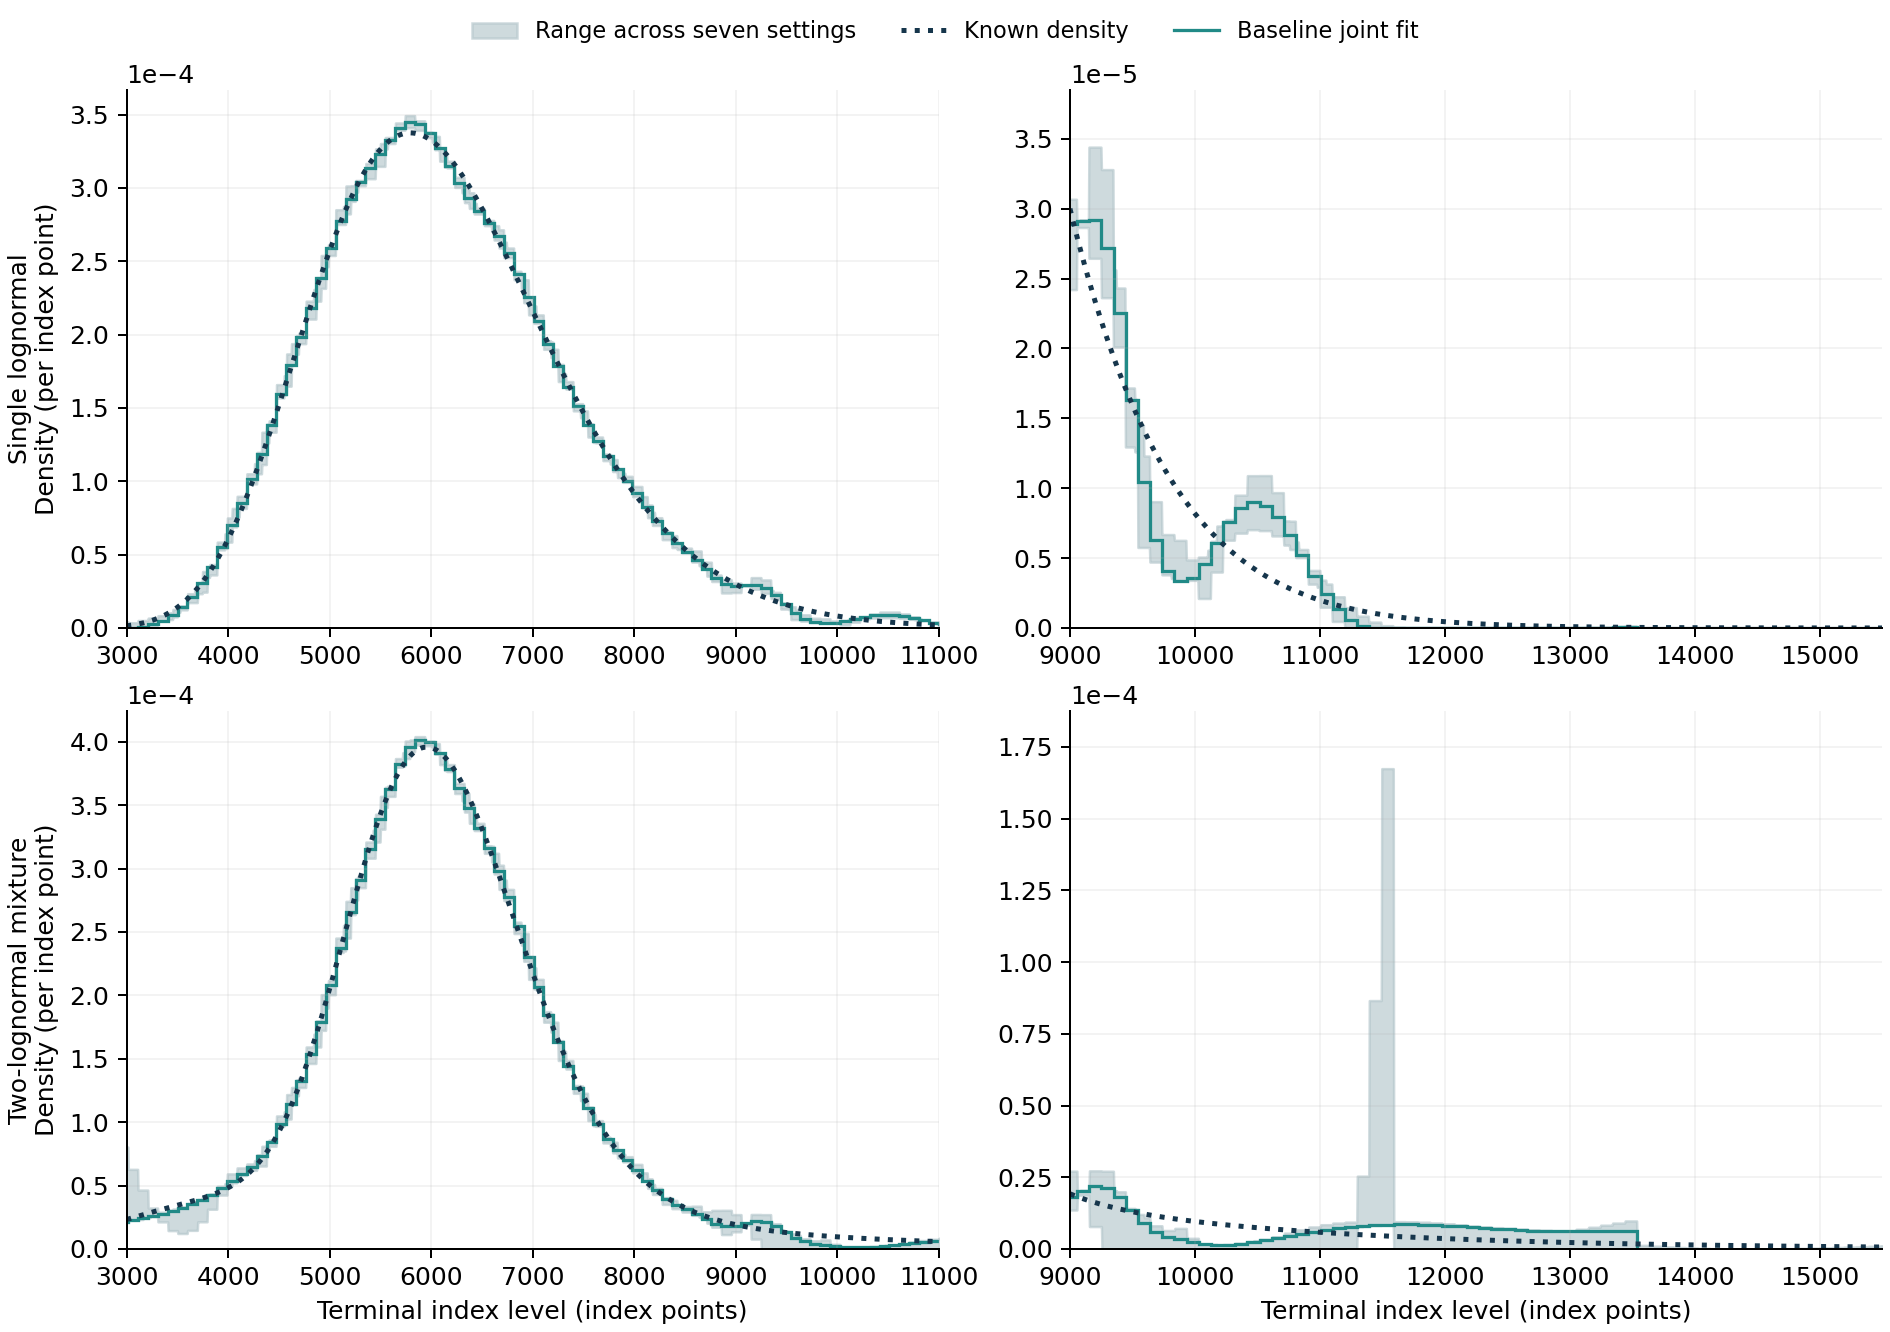




Figure 15. Known and baseline fitted densities at 365 days, with the pointwise range across all seven settings shaded. The upper row is the single-lognormal benchmark and the lower row is the two-lognormal mixture. Left panels show the central distribution; right panels enlarge the upper tail. Density is per index point. The shaded envelope is sampled for display and is not a probability density or a confidence band.

Figure 15 helps identify where changes occur. The baseline line is the actual histogram representation; the envelope combines extrema across different fitted models at each level. It need not integrate to one. Changing the support also changes where an estimator must assign exactly zero density, even though the known lognormal components have unbounded positive support.

The large spike in the lower-right envelope comes from the mixture fit on the narrow support. Its exported probabilities accumulate near the imposed upper endpoint, around 11,586 index points. All supplied strikes lie below that endpoint. This is an observed sensitivity to the artificial support boundary, not an additional mode in the known mixture density.



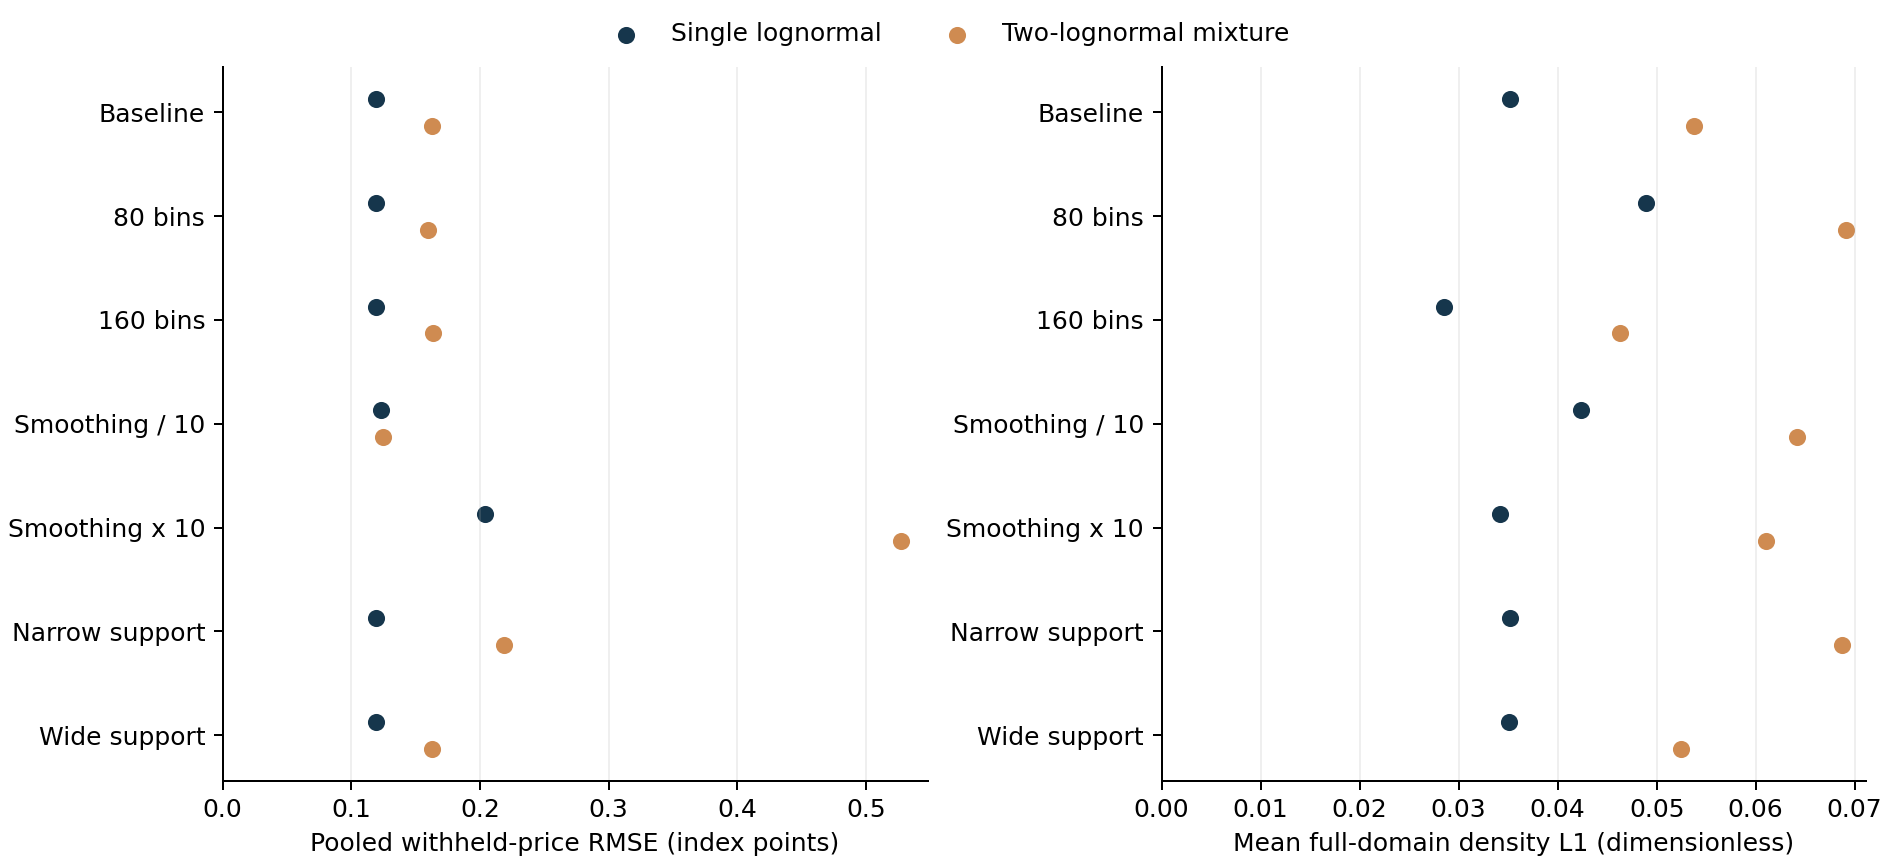




Figure 16. Pooled withheld clean-price RMSE and mean full-domain density error across the seven settings. Each point summarises all eight horizons for one benchmark. RMSE is in index points; integrated density error is dimensionless. The two horizontal axes represent different measures and should not be compared numerically to one another.

Figure 16 tests the distinction between price interpolation and density recovery. The fitting objective sees observed option prices and a smoothness penalty; it does not minimise the full-domain density error. Improving one reported metric is therefore not sufficient evidence of improving all aspects of the recovered distribution.

### 6. Tail probabilities and moments

Table 13. Known values and fitted ranges at 365 days across the seven declared settings. Probabilities are percentages; normalised variance is dimensionless. Ranges are sensitivity summaries, not confidence intervals.

| Benchmark | Quantity | Known value | Minimum fitted | Maximum fitted |
|---|---|---:|---:|---:|
| Single lognormal | P(S < 0.8F), % | 15.488190 | 15.479921 | 15.542850 |
| Single lognormal | P(S > 1.2F), % | 15.586281 | 15.541113 | 15.550680 |
| Single lognormal | P(S > 1.8F), % | 0.118709 | 0.010066 | 0.058278 |
| Single lognormal | Var(S/F) | 0.040811 | 0.040748 | 0.040811 |
| Two-lognormal mixture | P(S < 0.8F), % | 13.788289 | 13.782732 | 13.848692 |
| Two-lognormal mixture | P(S > 1.2F), % | 12.773293 | 12.725272 | 12.737735 |
| Two-lognormal mixture | P(S > 1.8F), % | 1.188550 | 1.745535 | 2.720848 |
| Two-lognormal mixture | Var(S/F) | 0.058223 | 0.054783 | 0.056258 |



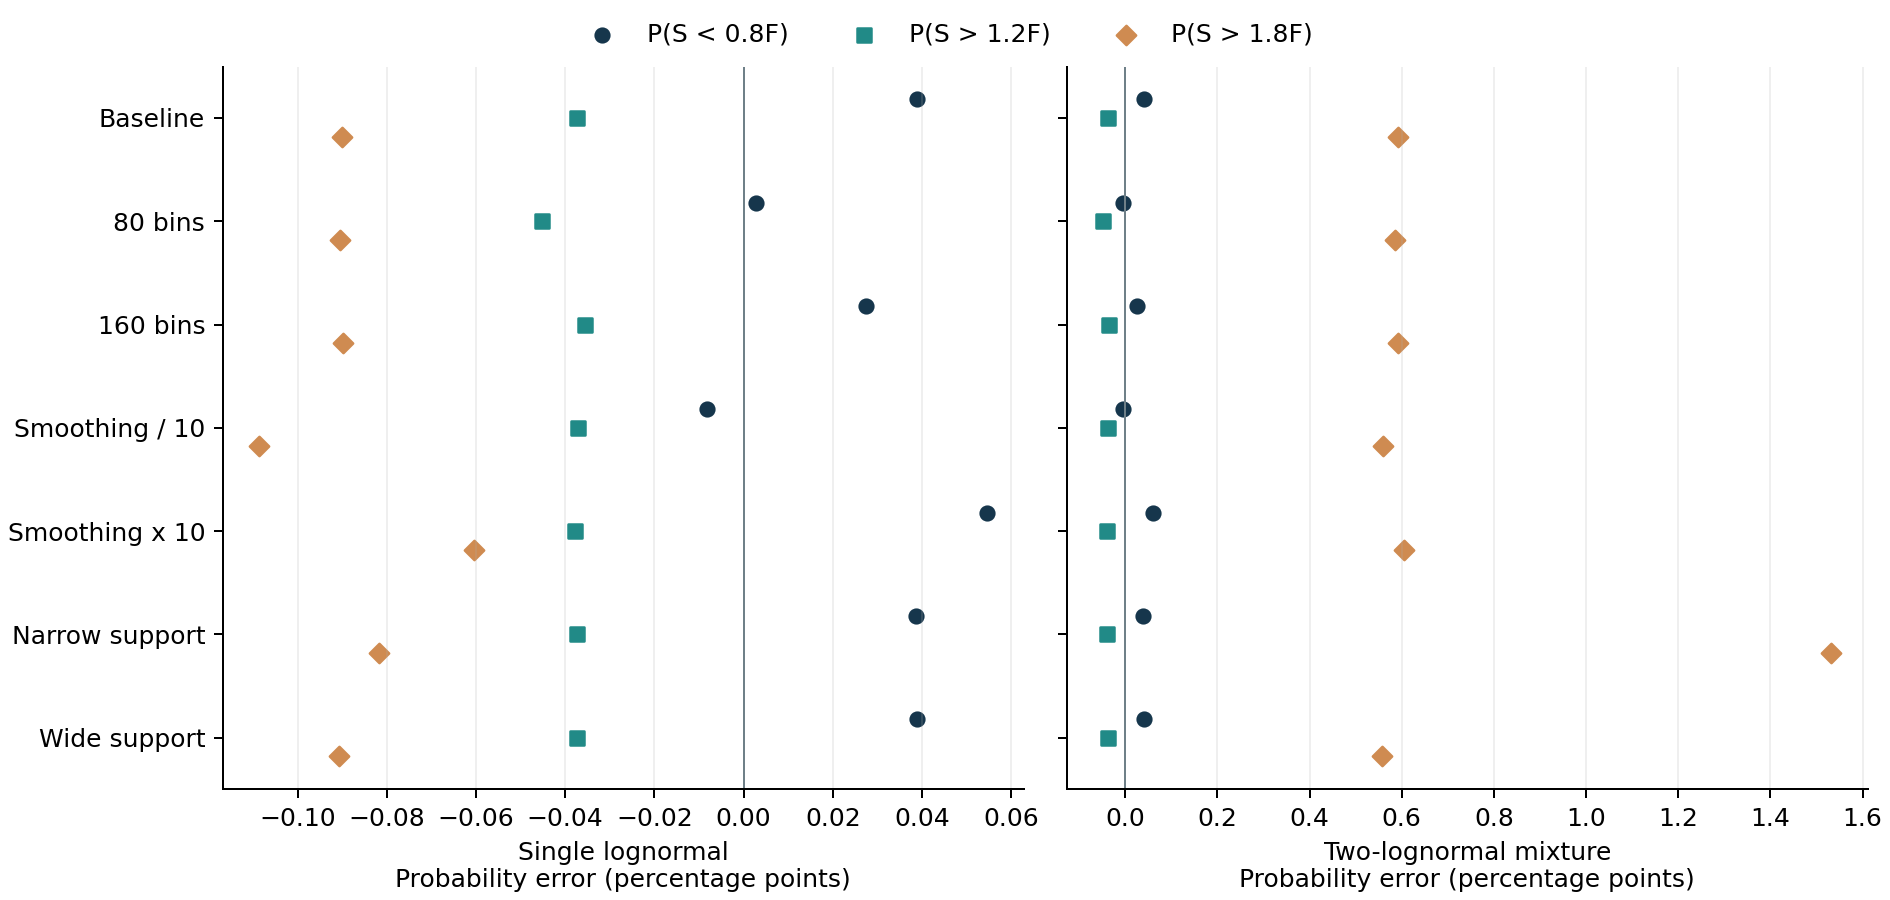




Figure 17. Fitted minus known probabilities at 365 days for the three events in Equation (24). Errors are measured in percentage points; the vertical zero line indicates agreement with the benchmark. Each panel contains the same seven modelling choices. A one-percentage-point error is an absolute probability difference of 0.01, not a 1% relative error.

For the single-lognormal benchmark at 365 days, the known probability above $1.8F$ is 0.1187%, while fitted values range from 0.0101% to 0.0583%. The largest absolute error across the two moderate-threshold probabilities is 0.0547 percentage points within these seven settings.

For the mixture benchmark at 365 days, the known probability above $1.8F$ is 1.1885%, while fitted values range from 1.7455% to 2.7208%. The largest absolute error across the two moderate-threshold probabilities is 0.0604 percentage points within these seven settings.

The far-tail estimates therefore require particular caution even though every fitted family passes the calendar check. For the mixture, every fitted normalised variance in Table 13 is below the known value, despite the overestimated probability above $1.8F$. A single tail-event probability does not determine variance: where probability is allocated farther into the tail also matters.

An apparently stable summary may still be biased, so Table 13 retains the known value beside the fitted range. Conversely, a visible local density bump need not produce a large error in every integrated tail probability. Reporting both the distribution and selected integrals makes these different conclusions assessable.

### 7. Numerical checks, reproducibility and remaining limits

All 14 joint fits pass the interval-level calendar check at $10^{-8}$, with a worst minimum gap of approximately -9.803e-10. Across the 112 marginal distributions, the largest mass and normalised-mean residuals are 3.175e-14 and 1.339e-12; the smallest raw bin mass is 5.206e-16. Signed numerical residuals are retained without clipping or renormalisation.

Every accepted solver round reports `Solved`; the largest iteration count in a round is 43. The maximum mismatch in the added residual-variable equations is 2.078e-13. The largest absolute primal–dual objective gap on the scaled problem is 9.563e-11. The largest density-integration error estimate is 1.925e-07, below the requested $2\times10^{-7}$ threshold. These estimates are convergence diagnostics, not rigorous integration bounds. The full solver and integration records remain in `results/robustness_validation.json`.

The study uses Clarabel 0.11.1 with explicit price-error and roughness variables. Equalities require those variables to equal the expressions already squared in Equation (12), so the mathematical objective and calendar constraints are unchanged. This avoids expanding the price-error squares into a matrix product. All 14 comparisons use the same formulation and solver. Its internal initialisation does not receive the known benchmark density or weights.

The change follows a concrete numerical failure: OSQP's original formulation did not meet its stopping rule for the mixture baseline, even after the iteration allowance was increased from 100,000 to 300,000. Trials with a rescaled objective and explicit residuals also failed to meet that rule. Those iterates were not included as successful fits. The earlier OSQP runner and its default behaviour remain available for Milestone 5.

As Goulart and Chen describe in their Clarabel research paper [15, §§1, 2.6], the solver handles convex quadratic objectives with conic constraints and checks numerical feasibility and optimality conditions. Here, linear equalities and inequalities encode the same programme. The objective scale is $10^6$, the absolute and relative duality-gap settings and feasibility setting are $10^{-10}$, and the allowance is 200 interior-point iterations per solve. The implementation pins the QDLDL linear solver and one solver thread. Solver iteration counts and residual definitions differ from OSQP's and should not be compared as though they were the same quantities. Only `Solved` status is accepted; the separate marginal and calendar thresholds are unchanged.

The all-strike check evaluates endpoints and eligible quadratic minima for adjacent fitted maturity pairs, as described by Equations (18)–(19). It is a floating-point check at discrete horizons. Passing it is distinct from accurately recovering a benchmark, and neither check validates the graphical joins between horizons in the earlier 3D companions.

Saved probability weights, quotes, metrics, solver histories and input checksums make the comparisons reproducible. The test suite separately integrates the mixture density and call payoff, checks its moments, verifies the penalty conversion on a known-curvature function, compares the two formulations on a small independently specified problem, and reconstructs reported probabilities from the exported bin masses. Numerical success is not an exact optimality certificate. Stellato and co-authors [13] remain the source for the earlier OSQP implementation, while [15] supports the new backend.

This study does not address repeated quote-noise realisations, alternative strike-coverage patterns, bid–ask-dependent errors, uncertain forwards or data-driven penalty selection. Its two benchmark families do not represent every form of market skew or tail behaviour. The next stage should test noise and quote coverage before an empirical application, with any tuning rule separated from the final evaluation data.

The candidate market snapshot remains unverified for calibration. Historical-date animation still requires suitable verified observations. Both earlier dynamic 3D companions remain in the cumulative project; this milestone adds static scientific comparisons for the paper. The first five notebooks, including the Figure 4 explanation placement, are preserved. Working lists of figures, tables, equations, abbreviations and symbols are extended, while the final title page, abstract, contents and page references remain scheduled for the combined paper.

The accompanying paper section, [Development challenges, corrective actions and lessons learned](research/development_reflection.md), records the problems encountered across Notebooks 1–6, including unsuccessful solver adjustments, the checks that supported each resolution and the limitations still open. It will be extended alongside subsequent notebooks and incorporated into the overall document.

### References

[1] B. Bahra (1997), “Implied risk-neutral probability density functions from option prices: theory and application,” Bank of England, Working Paper No. 66, §§3.5–3.6 and mathematical appendix. [Full paper](https://www.bankofengland.co.uk/-/media/boe/files/working-paper/1997/implied-risk-neutral-probability-density-functions-from-option-prices.pdf).

[7] T. A. Driscoll and R. J. Braun, *Fundamentals of Numerical Computation*, §5.4.2, Equation (5.4.9). [Author-maintained textbook](https://fncbook.com/finitediffs/).

[11] S. Boyd and L. Vandenberghe (2004), *Convex Optimization*. Cambridge University Press, §6.3. [Author-hosted book](https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf).

[12] J. Gatheral and A. Jacquier, “Arbitrage-free SVI volatility surfaces,” *Quantitative Finance*, vol. 14, no. 1, pp. 59–71; first published online 2013. [doi:10.1080/14697688.2013.819986](https://doi.org/10.1080/14697688.2013.819986). Consulted [author preprint](https://arxiv.org/abs/1204.0646v4), §2.1.

[13] B. Stellato, G. Banjac, P. Goulart, A. Bemporad and S. Boyd (2020), “OSQP: An Operator Splitting Solver for Quadratic Programs,” *Mathematical Programming Computation*, vol. 12, no. 4, pp. 637–672. [doi:10.1007/s12532-020-00179-2](https://doi.org/10.1007/s12532-020-00179-2); [author publication page](https://web.stanford.edu/~boyd/papers/osqp.html).

[14] A. M. Malz (2014), “A Simple and Reliable Way to Compute Option-Based Risk-Neutral Distributions,” Federal Reserve Bank of New York, Staff Report No. 677, June, §§2.3 and 3.2. [Publication page](https://www.newyorkfed.org/research/staff_reports/sr677.html); [full research paper](https://www.newyorkfed.org/medialibrary/media/research/staff_reports/sr677.pdf). This source supports the discussion of extrapolation and tail summaries; its spline estimator is not implemented here.

[15] P. J. Goulart and Y. Chen (2024), “Clarabel: An interior-point solver for conic programs with quadratic objectives,” research preprint, arXiv:2405.12762v1, 21 May, §§1 and 2.6. [Paper record](https://arxiv.org/abs/2405.12762v1); [full paper](https://arxiv.org/pdf/2405.12762). This is cited as a research preprint, not as a verified journal publication.
